In [16]:
import pandas as pd

matches = pd.read_csv('archive/matches.csv')
print(matches.shape)
print(matches.columns.tolist())
matches.head()

(1158, 25)
['match_id', 'season', 'match_number', 'stage', 'date', 'venue', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision', 'first_innings_score', 'first_innings_wickets', 'first_innings_overs', 'second_innings_score', 'second_innings_wickets', 'second_innings_overs', 'result', 'winner', 'win_by', 'win_margin', 'player_of_match', 'umpire1', 'umpire2', 'is_day_night']


,match_id,season,match_number,stage,date,venue,city,team1,team2,toss_winner,...,second_innings_wickets,second_innings_overs,result,winner,win_by,win_margin,player_of_match,umpire1,umpire2,is_day_night
0,M0001,2008,1,League,2008-03-13,Punjab Cricket Association Stadium,Mohali,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,...,8,15.4,normal,Kings XI Punjab,runs,81,Moeen Taylor,Aleem Dar,Marais Erasmus,False
1,M0002,2008,2,League,2008-03-14,Greenfield Intl Stadium,Thiruvananthapuram,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,...,3,18.6,normal,Kolkata Knight Riders,wickets,7,Shai Amla,Michael Gough,Simon Taufel,True
2,M0003,2008,3,League,2008-03-15,M. A. Chidambaram Stadium,Chennai,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,2,19.0,normal,Chennai Super Kings,runs,81,Lungi Warner,KN Ananthapadmanabhan,Michael Gough,True
3,M0004,2008,4,League,2008-03-16,DY Patil Stadium,Navi Mumbai,Chennai Super Kings,Deccan Chargers,Chennai Super Kings,...,1,17.4,normal,Deccan Chargers,runs,7,Denesh Cummins,Kumar Dharmasena,Simon Taufel,False
4,M0005,2008,5,League,2008-03-17,Sawai Mansingh Stadium,Jaipur,Rajasthan Royals,Kolkata Knight Riders,Kolkata Knight Riders,...,4,15.4,normal,Kolkata Knight Riders,runs,31,Ollie Siraj,Sundaram Ravi,KN Ananthapadmanabhan,False


In [17]:
# Important columns dekhte hain
important_cols = ['match_id', 'season', 'date', 'team1', 'team2', 
                  'toss_winner', 'winner', 'venue', 'city', 'stage']

print("=== Important Columns ===")
print(matches[important_cols].head(10))

print("\n=== Missing Values ===")
print(matches[important_cols].isnull().sum())

print("\n=== Kitne Seasons Hain ===")
print(sorted(matches['season'].unique()))

=== Important Columns ===
  match_id  season        date                team1  \
0    M0001    2008  2008-03-13      Kings XI Punjab   
1    M0002    2008  2008-03-14       Mumbai Indians   
2    M0003    2008  2008-03-15  Chennai Super Kings   
3    M0004    2008  2008-03-16  Chennai Super Kings   
4    M0005    2008  2008-03-17     Rajasthan Royals   
5    M0006    2008  2008-03-18      Kings XI Punjab   
6    M0007    2008  2008-03-20     Rajasthan Royals   
7    M0008    2008  2008-03-21      Kings XI Punjab   
8    M0009    2008  2008-03-23     Delhi Daredevils   
9    M0010    2008  2008-03-25  Chennai Super Kings   

                         team2                  toss_winner  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore   
1        Kolkata Knight Riders               Mumbai Indians   
2               Mumbai Indians          Chennai Super Kings   
3              Deccan Chargers          Chennai Super Kings   
4        Kolkata Knight Riders        Kolkata Knight 

In [18]:
# IPL Team → NSE Listed Sponsor Mapping
sponsor_map = {
    'Mumbai Indians': 'RELIANCE',
    'Chennai Super Kings': 'INDIACEM',
    'Kolkata Knight Riders': 'JSWSTEEL',
    'Royal Challengers Bangalore': 'UNITDSPR',
    'Delhi Daredevils': 'GMR',
    'Delhi Capitals': 'GMR',
    'Rajasthan Royals': 'STERLINGT',
    'Punjab Kings': 'CENTRALBK',
    'Kings XI Punjab': 'CENTRALBK',
    'Sunrisers Hyderabad': 'SUN',
    'Deccan Chargers': 'SUN'
}

# Matches mein sponsor column add karo
matches['winner_sponsor'] = matches['winner'].map(sponsor_map)

# Kitne matches mein sponsor mil gaya
print("Sponsor mapped matches:", matches['winner_sponsor'].notna().sum())
print("Total matches:", len(matches))
print("\nTeam-wise sponsor check:")
print(matches[['winner','winner_sponsor']].drop_duplicates().dropna())

Sponsor mapped matches: 1019
Total matches: 1158

Team-wise sponsor check:
                          winner winner_sponsor
0                Kings XI Punjab      CENTRALBK
1          Kolkata Knight Riders       JSWSTEEL
2            Chennai Super Kings       INDIACEM
3                Deccan Chargers            SUN
5               Delhi Daredevils            GMR
10                Mumbai Indians       RELIANCE
14              Rajasthan Royals      STERLINGT
18   Royal Challengers Bangalore       UNITDSPR
325          Sunrisers Hyderabad            SUN
696               Delhi Capitals            GMR
812                 Punjab Kings      CENTRALBK


In [19]:
import yfinance as yf
from datetime import datetime

# Sponsor stocks ki list
stocks = ['RELIANCE.NS', 'INDIACEM.NS', 'JSWSTEEL.NS', 
          'UNITDSPR.NS', 'SUN.NS', 'CENTRALBK.NS']

# IPL ka time period 2008 to 2025
print("Stock data download ho raha hai... thoda wait karo")

stock_data = yf.download(
    tickers=stocks,
    start='2008-01-01',
    end='2025-12-31',
    auto_adjust=True
)

print("Download complete!")
print("Shape:", stock_data.shape)
print(stock_data['Close'].tail())

Stock data download ho raha hai... thoda wait karo


$SUN.NS: possibly delisted; no price data found  (1d 2008-01-01 -> 2025-12-31)
[*********************100%***********************]  6 of 6 completed

1 Failed download:
['SUN.NS']: possibly delisted; no price data found  (1d 2008-01-01 -> 2025-12-31)


Download complete!
Shape: (4437, 31)
Ticker      CENTRALBK.NS  INDIACEM.NS  JSWSTEEL.NS  RELIANCE.NS  SUN.NS  \
Date                                                                      
2025-12-23     36.325577   441.700012  1096.800049  1570.699951     NaN   
2025-12-24     36.217930   436.299988  1091.300049  1558.199951     NaN   
2025-12-26     36.071140   441.299988  1094.400024  1559.199951     NaN   
2025-12-29     35.797138   448.049988  1092.599976  1545.599976     NaN   
2025-12-30     36.266865   441.899994  1111.599976  1539.800049     NaN   

Ticker      UNITDSPR.NS  
Date                     
2025-12-23  1435.310303  
2025-12-24  1415.698975  
2025-12-26  1421.970703  
2025-12-29  1423.264771  
2025-12-30  1417.391357  


In [20]:
# SUN.NS ki jagah SUNPHARMA.NS download karo
sun_data = yf.download(
    tickers=['SUNPHARMA.NS'],
    start='2008-01-01',
    end='2025-12-31',
    auto_adjust=True
)

# Sponsor map update karo
sponsor_map['Sunrisers Hyderabad'] = 'SUNPHARMA'
sponsor_map['Deccan Chargers'] = 'SUNPHARMA'
matches['winner_sponsor'] = matches['winner'].map(sponsor_map)

# Sun data ko main stock_data mein add karo
stock_data[('Close', 'SUNPHARMA.NS')] = sun_data['Close']

print("SUNPHARMA data added!")
print("Sun Pharma sample:")
print(sun_data['Close'].tail())

[*********************100%***********************]  1 of 1 completed

SUNPHARMA data added!
Sun Pharma sample:
Ticker      SUNPHARMA.NS
Date                    
2025-12-23   1744.567627
2025-12-24   1725.789673
2025-12-26   1708.402588
2025-12-29   1706.117310
2025-12-30   1709.098022


In [21]:
import sqlite3

# Database banao
conn = sqlite3.connect('ipl_stock.db')

# 1. Matches table save karo
matches.to_sql('matches', conn, if_exists='replace', index=False)

# 2. Stock prices table banao
close_prices = stock_data['Close'].reset_index()
close_prices.columns = ['date'] + [col.replace('.NS', '') for col in close_prices.columns[1:]]
close_prices.to_sql('stock_prices', conn, if_exists='replace', index=False)

# Verify karo
print("=== Tables in Database ===")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

print("\n=== Matches table - first 3 rows ===")
print(pd.read_sql("SELECT match_id, date, winner, winner_sponsor FROM matches LIMIT 3", conn))

print("\n=== Stock prices table - first 3 rows ===")
print(pd.read_sql("SELECT * FROM stock_prices LIMIT 3", conn))

print("\nDatabase saved as: ipl_stock.db ✅")

=== Tables in Database ===
                 name
0         event_study
1  sentiment_analysis
2             matches
3        stock_prices

=== Matches table - first 3 rows ===
  match_id        date                 winner winner_sponsor
0    M0001  2008-03-13        Kings XI Punjab      CENTRALBK
1    M0002  2008-03-14  Kolkata Knight Riders       JSWSTEEL
2    M0003  2008-03-15    Chennai Super Kings       INDIACEM

=== Stock prices table - first 3 rows ===
                  date   CENTRALBK    INDIACEM    JSWSTEEL    RELIANCE   SUN  \
0  2008-01-01 00:00:00   97.910385  258.554626  108.731529  286.066711  None   
1  2008-01-02 00:00:00  102.057671  257.131256  107.470551  287.422577  None   
2  2008-01-03 00:00:00   99.776672  249.763031  110.622978  291.635864  None   

  UNITDSPR   SUNPHARMA  
0     None  104.718758  
1     None  103.556061  
2     None   99.285683  

Database saved as: ipl_stock.db ✅


In [22]:
import numpy as np

# Date column ko datetime format mein convert karo
matches['date'] = pd.to_datetime(matches['date'])
close_prices['date'] = pd.to_datetime(close_prices['date'])

# Sirf mapped matches lo
mapped_matches = matches[matches['winner_sponsor'].notna()].copy()

results = []

for _, match in mapped_matches.iterrows():
    sponsor = match['winner_sponsor']
    match_date = match['date']
    
    # Stock data us sponsor ka
    if sponsor not in close_prices.columns:
        continue
    
    stock = close_prices[['date', sponsor]].dropna()
    stock = stock.sort_values('date').reset_index(drop=True)
    
    # Match date ke baad wala trading day dhundho
    future = stock[stock['date'] > match_date]
    before = stock[stock['date'] <= match_date]
    
    if len(future) < 2 or len(before) < 1:
        continue
    
    price_day0 = before.iloc[-1][sponsor]  # Match day price
    price_day1 = future.iloc[0][sponsor]   # D+1 price
    price_day2 = future.iloc[1][sponsor]   # D+2 price
    
    # Return calculate karo
    return_d1 = ((price_day1 - price_day0) / price_day0) * 100
    return_d2 = ((price_day2 - price_day0) / price_day0) * 100
    
    results.append({
        'match_id': match['match_id'],
        'date': match_date,
        'season': match['season'],
        'winner': match['winner'],
        'sponsor': sponsor,
        'stage': match['stage'],
        'price_match_day': round(price_day0, 2),
        'price_d1': round(price_day1, 2),
        'return_d1_pct': round(return_d1, 3),
        'return_d2_pct': round(return_d2, 3)
    })

event_df = pd.DataFrame(results)
print(f"Total events analyzed: {len(event_df)}")
print("\nSample results:")
print(event_df[['winner', 'sponsor', 'date', 'return_d1_pct']].head(10))
print("\nAverage D+1 return after WIN:")
print(event_df.groupby('sponsor')['return_d1_pct'].mean().round(3))

Total events analyzed: 673

Sample results:
                  winner    sponsor       date  return_d1_pct
0        Kings XI Punjab  CENTRALBK 2008-03-13          3.599
1  Kolkata Knight Riders   JSWSTEEL 2008-03-14         -4.595
2    Chennai Super Kings   INDIACEM 2008-03-15        -11.088
3        Deccan Chargers  SUNPHARMA 2008-03-16         -3.017
4  Kolkata Knight Riders   JSWSTEEL 2008-03-17         -0.022
5  Kolkata Knight Riders   JSWSTEEL 2008-03-23        -12.204
6  Kolkata Knight Riders   JSWSTEEL 2008-03-25         -1.394
7         Mumbai Indians   RELIANCE 2008-03-27          3.596
8  Kolkata Knight Riders   JSWSTEEL 2008-03-28          0.226
9        Kings XI Punjab  CENTRALBK 2008-03-31          0.403

Average D+1 return after WIN:
sponsor
CENTRALBK   -0.064
INDIACEM    -0.163
JSWSTEEL     0.440
RELIANCE     0.184
SUNPHARMA    0.511
UNITDSPR     0.591
Name: return_d1_pct, dtype: float64


In [23]:
# Event results database mein save karo
event_df.to_sql('event_study', conn, if_exists='replace', index=False)

# AB INTERVIEWER WALI SQL QUERY
print("=== TOP SQL QUERY - Win ke baad best performing sponsors ===")
query = """
SELECT 
    winner,
    sponsor,
    COUNT(*) as total_wins,
    ROUND(AVG(return_d1_pct), 3) as avg_d1_return,
    ROUND(AVG(return_d2_pct), 3) as avg_d2_return,
    SUM(CASE WHEN return_d1_pct > 0 THEN 1 ELSE 0 END) as positive_days,
    ROUND(100.0 * SUM(CASE WHEN return_d1_pct > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as win_rate_pct
FROM event_study
GROUP BY winner, sponsor
ORDER BY avg_d1_return DESC
"""
result = pd.read_sql(query, conn)
print(result.to_string())

=== TOP SQL QUERY - Win ke baad best performing sponsors ===
                        winner    sponsor  total_wins  avg_d1_return  avg_d2_return  positive_days  win_rate_pct
0              Deccan Chargers  SUNPHARMA          31          1.500          0.806             21          67.7
1  Royal Challengers Bangalore   UNITDSPR          19          0.591          0.672             13          68.4
2        Kolkata Knight Riders   JSWSTEEL         128          0.440          0.733             68          53.1
3               Mumbai Indians   RELIANCE         130          0.184          0.321             68          52.3
4          Sunrisers Hyderabad  SUNPHARMA          93          0.181          0.287             42          45.2
5                 Punjab Kings  CENTRALBK          47          0.066          0.012             17          36.2
6              Kings XI Punjab  CENTRALBK          96         -0.127          0.260             40          41.7
7          Chennai Super Kings   IN

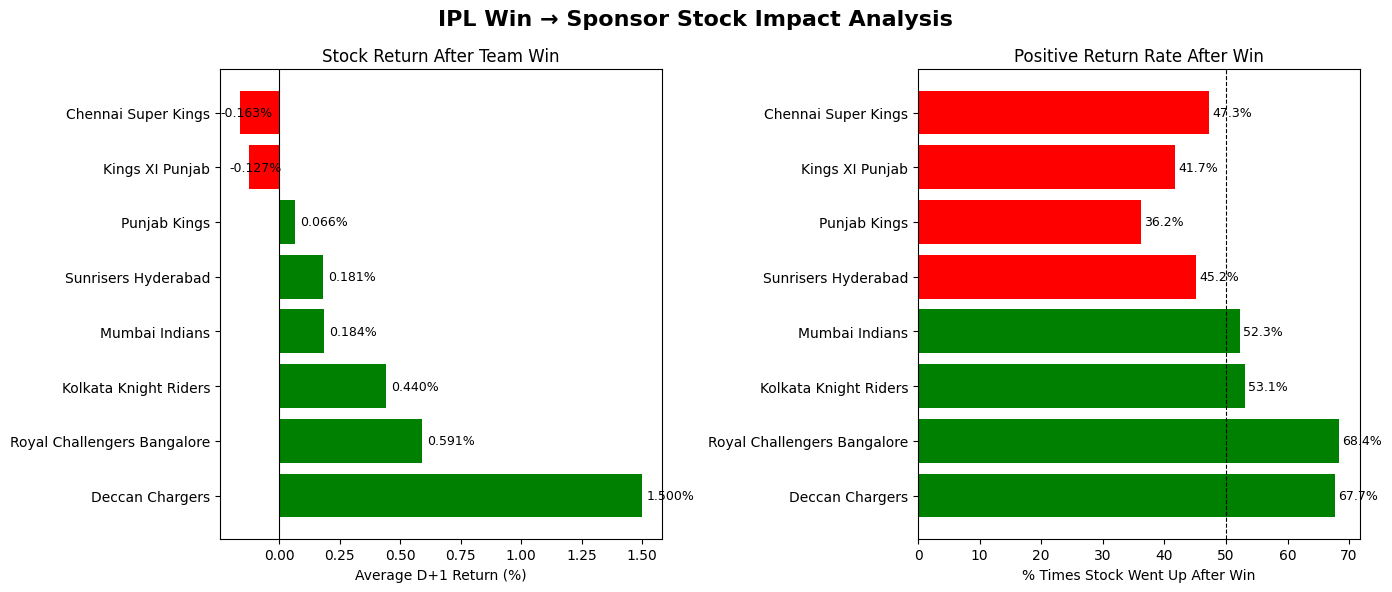

Chart saved as ipl_stock_impact.png ✅


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('IPL Win → Sponsor Stock Impact Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Average D+1 Return by Team
colors = ['green' if x > 0 else 'red' for x in result['avg_d1_return']]
axes[0].barh(result['winner'], result['avg_d1_return'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Average D+1 Return (%)')
axes[0].set_title('Stock Return After Team Win')
for i, v in enumerate(result['avg_d1_return']):
    axes[0].text(v + 0.02 if v >= 0 else v - 0.08, i, f'{v:.3f}%', va='center', fontsize=9)

# Chart 2 — Win Rate (% times stock went up after win)
colors2 = ['green' if x > 50 else 'red' for x in result['win_rate_pct']]
axes[1].barh(result['winner'], result['win_rate_pct'], color=colors2)
axes[1].axvline(x=50, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('% Times Stock Went Up After Win')
axes[1].set_title('Positive Return Rate After Win')
for i, v in enumerate(result['win_rate_pct']):
    axes[1].text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ipl_stock_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ipl_stock_impact.png ✅")

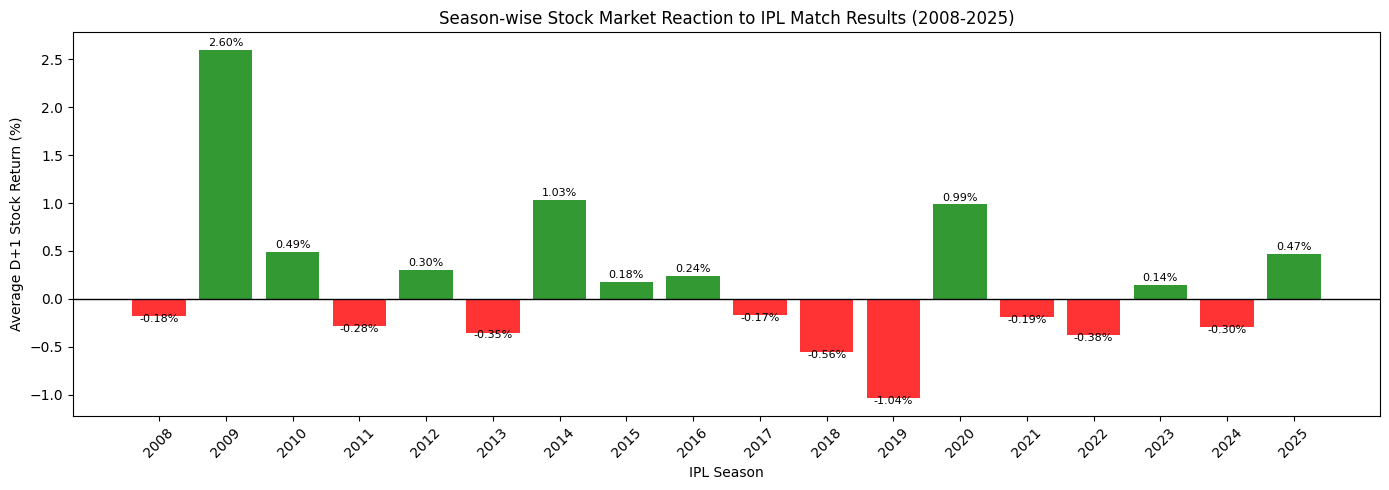

Season chart saved! ✅
    season  avg_return  total_matches  positive_pct
0     2008   -0.184514             37     54.054054
1     2009    2.600410             39     74.358974
2     2010    0.493216             37     59.459459
3     2011   -0.284706             34     38.235294
4     2012    0.299533             30     56.666667
5     2013   -0.353400             30     33.333333
6     2014    1.028949             39     61.538462
7     2015    0.176196             46     56.521739
8     2016    0.238619             21     52.380952
9     2017   -0.172313             32     43.750000
10    2018   -0.557628             43     39.534884
11    2019   -1.041152             33     30.303030
12    2020    0.985000             42     52.380952
13    2021   -0.191970             33     39.393939
14    2022   -0.380630             46     41.304348
15    2023    0.143810             42     50.000000
16    2024   -0.296293             41     39.024390
17    2025    0.465687             48     

In [25]:
# Season wise average return
season_analysis = event_df.groupby('season').agg(
    avg_return=('return_d1_pct', 'mean'),
    total_matches=('match_id', 'count'),
    positive_pct=('return_d1_pct', lambda x: (x > 0).mean() * 100)
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['green' if x > 0 else 'red' for x in season_analysis['avg_return']]
bars = ax.bar(season_analysis['season'], season_analysis['avg_return'], color=colors, alpha=0.8)

ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('IPL Season')
ax.set_ylabel('Average D+1 Stock Return (%)')
ax.set_title('Season-wise Stock Market Reaction to IPL Match Results (2008-2025)')
ax.set_xticks(season_analysis['season'])
ax.set_xticklabels(season_analysis['season'], rotation=45)

for bar, val in zip(bars, season_analysis['avg_return']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('season_wise_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Season chart saved! ✅")
print(season_analysis.to_string())

=== Sentiment Analysis Results ===
                                                      headline  polarity sentiment
0  Mumbai Indians crush Chennai Super Kings in thrilling match     0.292  Positive
1         Rohit Sharma leads Mumbai Indians to massive victory     0.000   Neutral
2                  Reliance Industries quarterly profits surge     0.000   Neutral
3           KKR dominates with outstanding bowling performance     0.500  Positive
4                  JSW Steel reports record production numbers     0.000   Neutral
5                   Chennai Super Kings suffer shocking defeat    -0.333  Negative
6                    RCB wins by 8 wickets in dominant display     0.300  Positive
7               United Spirits revenue grows after RCB victory     0.000   Neutral
8    Deccan Chargers stun Mumbai Indians in last over thriller     0.000   Neutral
9        Sun Pharma stock rises amid positive market sentiment     0.227  Positive

Sentiment data saved to database ✅


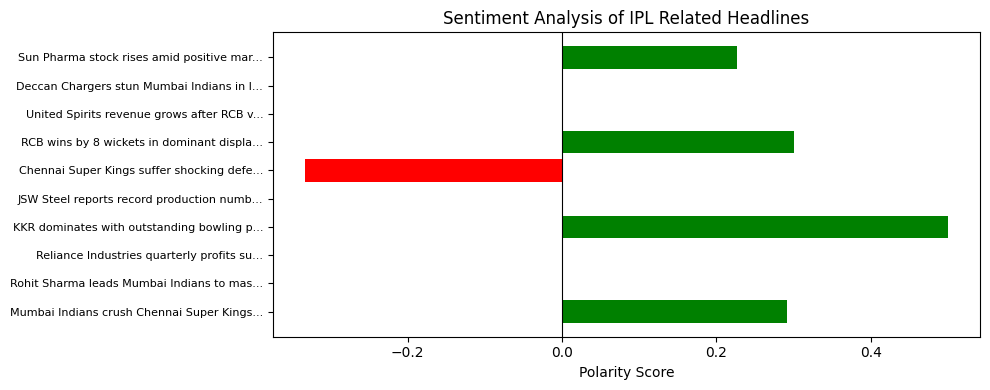

Sentiment chart saved! ✅


In [26]:
from textblob import TextBlob
import random

# Sample IPL related headlines banate hain
# (Real project mein news scrape karte hain — abhi sample se kaam chalate hain)

sample_headlines = [
    "Mumbai Indians crush Chennai Super Kings in thrilling match",
    "Rohit Sharma leads Mumbai Indians to massive victory",
    "Reliance Industries quarterly profits surge",
    "KKR dominates with outstanding bowling performance",
    "JSW Steel reports record production numbers",
    "Chennai Super Kings suffer shocking defeat",
    "RCB wins by 8 wickets in dominant display",
    "United Spirits revenue grows after RCB victory",
    "Deccan Chargers stun Mumbai Indians in last over thriller",
    "Sun Pharma stock rises amid positive market sentiment"
]

# Sentiment analyze karo
sentiment_results = []
for headline in sample_headlines:
    blob = TextBlob(headline)
    sentiment_results.append({
        'headline': headline,
        'polarity': round(blob.sentiment.polarity, 3),
        'subjectivity': round(blob.sentiment.subjectivity, 3),
        'sentiment': 'Positive' if blob.sentiment.polarity > 0 else ('Negative' if blob.sentiment.polarity < 0 else 'Neutral')
    })

sentiment_df = pd.DataFrame(sentiment_results)
print("=== Sentiment Analysis Results ===")
print(sentiment_df[['headline', 'polarity', 'sentiment']].to_string())

# Sentiment save karo database mein
sentiment_df.to_sql('sentiment_analysis', conn, if_exists='replace', index=False)
print("\nSentiment data saved to database ✅")

# Quick chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if s == 'Positive' else 'red' if s == 'Negative' else 'gray' 
          for s in sentiment_df['sentiment']]
ax.barh(range(len(sentiment_df)), sentiment_df['polarity'], color=colors)
ax.set_yticks(range(len(sentiment_df)))
ax.set_yticklabels([h[:40]+'...' if len(h)>40 else h for h in sentiment_df['headline']], fontsize=8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Sentiment Analysis of IPL Related Headlines')
ax.set_xlabel('Polarity Score')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sentiment chart saved! ✅")

In [27]:
# Streamlit app ka code file mein likhte hain
streamlit_code = '''
import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

st.set_page_config(page_title="IPL Pulse", page_icon="🏏", layout="wide")

st.title("🏏 IPL Pulse — Cricket & Stock Market Analyzer")
st.markdown("*Analyzing IPL match results impact on NSE sponsor stocks (2008-2025)*")

conn = sqlite3.connect('ipl_stock.db')

col1, col2, col3 = st.columns(3)

total = pd.read_sql("SELECT COUNT(*) as c FROM event_study", conn).iloc[0,0]
seasons = pd.read_sql("SELECT COUNT(DISTINCT season) as c FROM event_study", conn).iloc[0,0]
positive = pd.read_sql("SELECT ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as c FROM event_study", conn).iloc[0,0]

col1.metric("Total Events Analyzed", f"{total}")
col2.metric("IPL Seasons Covered", f"{seasons}")
col3.metric("Positive Return Rate", f"{positive}%")

st.divider()

st.subheader("📊 Team-wise Stock Impact After Win")
query = """
SELECT winner, sponsor,
    COUNT(*) as total_wins,
    ROUND(AVG(return_d1_pct),3) as avg_d1_return,
    ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as win_rate_pct
FROM event_study
GROUP BY winner, sponsor
ORDER BY avg_d1_return DESC
"""
df = pd.read_sql(query, conn)
st.dataframe(df, use_container_width=True)

st.subheader("📈 Season-wise Average Return")
season_df = pd.read_sql("""
    SELECT season, ROUND(AVG(return_d1_pct),3) as avg_return
    FROM event_study GROUP BY season ORDER BY season
""", conn)

fig, ax = plt.subplots(figsize=(12,4))
colors = ['green' if x > 0 else 'red' for x in season_df['avg_return']]
ax.bar(season_df['season'], season_df['avg_return'], color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Season')
ax.set_ylabel('Avg D+1 Return (%)')
ax.set_title('Stock Market Reaction by IPL Season')
plt.xticks(rotation=45)
st.pyplot(fig)

st.subheader("🔍 Match-level Explorer")
teams = ['All'] + sorted(pd.read_sql("SELECT DISTINCT winner FROM event_study", conn)['winner'].tolist())
selected = st.selectbox("Select Team", teams)

if selected == 'All':
    data = pd.read_sql("SELECT date, winner, sponsor, return_d1_pct, return_d2_pct, stage FROM event_study ORDER BY date DESC LIMIT 50", conn)
else:
    data = pd.read_sql(f"SELECT date, winner, sponsor, return_d1_pct, return_d2_pct, stage FROM event_study WHERE winner='{selected}' ORDER BY date DESC", conn)

st.dataframe(data, use_container_width=True)
conn.close()
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("app.py created! ✅")
print("Ab terminal mein yeh command run karo:")
print("streamlit run app.py")

UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f3cf' in position 152: character maps to <undefined>

In [ ]:
streamlit_code = '''import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

st.set_page_config(page_title="IPL Pulse", page_icon="cricket", layout="wide")

st.title("IPL Pulse - Cricket & Stock Market Analyzer")
st.markdown("*Analyzing IPL match results impact on NSE sponsor stocks (2008-2025)*")

conn = sqlite3.connect('ipl_stock.db')

col1, col2, col3 = st.columns(3)

total = pd.read_sql("SELECT COUNT(*) as c FROM event_study", conn).iloc[0,0]
seasons = pd.read_sql("SELECT COUNT(DISTINCT season) as c FROM event_study", conn).iloc[0,0]
positive = pd.read_sql("SELECT ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as c FROM event_study", conn).iloc[0,0]

col1.metric("Total Events Analyzed", f"{total}")
col2.metric("IPL Seasons Covered", f"{seasons}")
col3.metric("Positive Return Rate", f"{positive}%")

st.divider()

st.subheader("Team-wise Stock Impact After Win")
query = """
SELECT winner, sponsor,
    COUNT(*) as total_wins,
    ROUND(AVG(return_d1_pct),3) as avg_d1_return,
    ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as win_rate_pct
FROM event_study
GROUP BY winner, sponsor
ORDER BY avg_d1_return DESC
"""
df = pd.read_sql(query, conn)
st.dataframe(df, use_container_width=True)

st.subheader("Season-wise Average Return")
season_df = pd.read_sql("""
    SELECT season, ROUND(AVG(return_d1_pct),3) as avg_return
    FROM event_study GROUP BY season ORDER BY season
""", conn)

fig, ax = plt.subplots(figsize=(12,4))
colors = ["green" if x > 0 else "red" for x in season_df["avg_return"]]
ax.bar(season_df["season"], season_df["avg_return"], color=colors)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Season")
ax.set_ylabel("Avg D+1 Return (%)")
ax.set_title("Stock Market Reaction by IPL Season")
plt.xticks(rotation=45)
st.pyplot(fig)

st.subheader("Match-level Explorer")
teams = ["All"] + sorted(pd.read_sql("SELECT DISTINCT winner FROM event_study", conn)["winner"].tolist())
selected =

_IncompleteInputError: incomplete input (1378928294.py, line 1)

In [ ]:
code = [
    "import streamlit as st",
    "import pandas as pd",
    "import sqlite3",
    "import matplotlib.pyplot as plt",
    "",
    "st.set_page_config(page_title='IPL Pulse', layout='wide')",
    "st.title('IPL Pulse - Cricket and Stock Market Analyzer')",
    "st.markdown('Analyzing IPL match results impact on NSE sponsor stocks 2008-2025')",
    "",
    "conn = sqlite3.connect('ipl_stock.db')",
    "",
    "col1, col2, col3 = st.columns(3)",
    "total = pd.read_sql('SELECT COUNT(*) as c FROM event_study', conn).iloc[0,0]",
    "seasons = pd.read_sql('SELECT COUNT(DISTINCT season) as c FROM event_study', conn).iloc[0,0]",
    "positive = pd.read_sql('SELECT ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as c FROM event_study', conn).iloc[0,0]",
    "col1.metric('Total Events Analyzed', str(total))",
    "col2.metric('IPL Seasons Covered', str(seasons))",
    "col3.metric('Positive Return Rate', str(positive)+'%')",
    "",
    "st.divider()",
    "st.subheader('Team-wise Stock Impact After Win')",
    "query = 'SELECT winner, sponsor, COUNT(*) as total_wins, ROUND(AVG(return_d1_pct),3) as avg_d1_return, ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as win_rate_pct FROM event_study GROUP BY winner, sponsor ORDER BY avg_d1_return DESC'",
    "df = pd.read_sql(query, conn)",
    "st.dataframe(df, use_container_width=True)",
    "",
    "st.subheader('Season-wise Average Return')",
    "season_df = pd.read_sql('SELECT season, ROUND(AVG(return_d1_pct),3) as avg_return FROM event_study GROUP BY season ORDER BY season', conn)",
    "fig, ax = plt.subplots(figsize=(12,4))",
    "colors = ['green' if x > 0 else 'red' for x in season_df['avg_return']]",
    "ax.bar(season_df['season'], season_df['avg_return'], color=colors)",
    "ax.axhline(y=0, color='black', linewidth=0.8)",
    "ax.set_xlabel('Season')",
    "ax.set_ylabel('Avg D+1 Return (%)')",
    "ax.set_title('Stock Market Reaction by IPL Season')",
    "plt.xticks(rotation=45)",
    "st.pyplot(fig)",
    "",
    "st.subheader('Match-level Explorer')",
    "teams = ['All'] + sorted(pd.read_sql('SELECT DISTINCT winner FROM event_study',

SyntaxError: unterminated string literal (detected at line 40) (99068923.py, line 40)

In [ ]:
code = [
    "import streamlit as st",
    "import pandas as pd",
    "import sqlite3",
    "import matplotlib.pyplot as plt",
    "",
    "st.set_page_config(page_title='IPL Pulse', layout='wide')",
    "st.title('IPL Pulse - Cricket and Stock Market Analyzer')",
    "st.markdown('Analyzing IPL match results impact on NSE sponsor stocks 2008-2025')",
    "",
    "conn = sqlite3.connect('ipl_stock.db')",
    "",
    "col1, col2, col3 = st.columns(3)",
    "total = pd.read_sql('SELECT COUNT(*) as c FROM event_study', conn).iloc[0,0]",
    "seasons = pd.read_sql('SELECT COUNT(DISTINCT season) as c FROM event_study', conn).iloc[0,0]",
    "positive = pd.read_sql('SELECT ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as c FROM event_study', conn).iloc[0,0]",
    "col1.metric('Total Events Analyzed', str(total))",
    "col2.metric('IPL Seasons Covered', str(seasons))",
    "col3.metric('Positive Return Rate', str(positive)+'%')",
    "",
    "st.divider()",
    "st.subheader('Team-wise Stock Impact After Win')",
    "query = 'SELECT winner, sponsor, COUNT(*) as total_wins, ROUND(AVG(return_d1_pct),3) as avg_d1_return, ROUND(100.0*SUM(CASE WHEN return_d1_pct>0 THEN 1 ELSE 0 END)/COUNT(*),1) as win_rate_pct FROM event_study GROUP BY winner, sponsor ORDER BY avg_d1_return DESC'",
    "df = pd.read_sql(query, conn)",
    "st.dataframe(df, use_container_width=True)",
    "",
    "st.subheader('Season-wise Average Return')",
    "season_df = pd.read_sql('SELECT season, ROUND(AVG(return_d1_pct),3) as avg_return FROM event_study GROUP BY season ORDER BY season', conn)",
    "fig, ax = plt.subplots(figsize=(12,4))",
    "colors = ['green' if x > 0 else 'red' for x in season_df['avg_return']]",
    "ax.bar(season_df['season'], season_df['avg_return'], color=colors)",
    "ax.axhline(y=0, color='black', linewidth=0.8)",
    "ax.set_xlabel('Season')",
    "ax.set_ylabel('Avg D+1 Return (%)')",
    "ax.set_title('Stock Market Reaction by IPL Season')",
    "plt.xticks(rotation=45)",
    "st.pyplot(fig)",
    "",
    "st.subheader('Match-level Explorer')",
    "teams = ['All'] + sorted(pd.read_sql('SELECT DISTINCT winner FROM event_study', conn)['winner'].tolist())",
    "selected = st.selectbox('Select Team', teams)",
    "if selected == 'All':",
    "    data = pd.read_sql('SELECT date, winner, sponsor, return_d1_pct, return_d2_pct, stage FROM event_study ORDER BY date DESC LIMIT 50', conn)",
    "else:",
    "    data = pd.read_sql('SELECT date, winner, sponsor, return_d1_pct, return_d2_pct, stage FROM event_study WHERE winner=\"' + selected + '\" ORDER BY date DESC', conn)",
    "st.dataframe(data, use_container_width=True)",
    "conn.close()",
]

with open('app.py', 'w', encoding='utf-8') as f:
    f.write('\n'.join(code))

print("app.py created successfully!")

app.py created successfully!
